# 📐 Boston Konut Fiyatları — Güç Dönüşümleri (Yeo-Johnson & Box-Cox)

**🇹🇷 Türkçe:**
Bu notebook bir ensemble modeli değil, klasik **Boston Housing** verisinde (506 satır) `PowerTransformer` (Yeo-Johnson) ve `boxcox` (Box-Cox) dönüşümlerinin bir `LinearRegression` modelinin performansını nasıl etkilediğini inceleyen odaklı bir çalışma. "Ensemble Techniques" klasöründe duruyor ama esas konusu **özellik/hedef dönüşümü**; buradaki Box-Cox tekniği, aynı günün ilerleyen saatlerinde `lightgbm_regression.ipynb`'de hedef değişkene uygulanan dönüşümün provası niteliğinde.

**🇬🇧 English:**
This notebook isn't an ensemble method — it's a focused study on the classic **Boston Housing** dataset (506 rows), examining how `PowerTransformer` (Yeo-Johnson) and `boxcox` (Box-Cox) affect a `LinearRegression` model's performance. It lives in the "Ensemble Techniques" folder, but its real subject is **feature/target transformation**; the Box-Cox technique used here is effectively a dry run for the same transform applied to the target in `lightgbm_regression.ipynb` later the same day.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
`numpy`, `matplotlib`, `seaborn`, `pandas` ve `PowerTransformer` yükleniyor.

**🇬🇧 English:**
`numpy`, `matplotlib`, `seaborn`, `pandas`, and `PowerTransformer` are imported.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import PowerTransformer

## 📥 1. Veri Setini Yükleme / Load the Boston Housing Dataset

**🇹🇷 Türkçe:**
Veri, orijinal UCI formatında geliyor: **başlıksız**, boşlukla ayrılmış ham metin (`header=None, delimiter=r"\s+"`), bu yüzden kolon isimleri elle veriliyor:

| Kolon | Anlamı |
|---|---|
| `CRIM` | Kişi başı suç oranı |
| `ZN` | 25.000 ft²'den büyük arsalar için ayrılmış konut alanı yüzdesi |
| `INDUS` | Sanayi (perakende olmayan iş) alanı yüzdesi |
| `CHAS` | Charles Nehri sınırı (1) / değil (0) — ikili |
| `NOX` | Azot oksit konsantrasyonu |
| `RM` | Konut başına ortalama oda sayısı |
| `AGE` | 1940 öncesi inşa edilmiş konut yüzdesi |
| `DIS` | Boston'daki 5 iş merkezine ağırlıklı uzaklık |
| `RAD` | Radyal otoyollara erişilebilirlik endeksi |
| `TAX` | 10.000$'lık emlak vergisi oranı |
| `PTRATIO` | Öğrenci-öğretmen oranı |
| `B` | Siyahi nüfus oranına dayalı bir formül — bu kolon, veri setinin sklearn'den kaldırılma gerekçelerinden biri olarak sıkça anılır |
| `LSTAT` | Düşük gelir grubundaki nüfus yüzdesi |
| `MEDV` | **Hedef değişken** — medyan konut değeri (binlik $) |

**🇬🇧 English:**
The data arrives in the original UCI format: **no header**, whitespace-delimited raw text (`header=None, delimiter=r"\s+"`), so column names are supplied manually:

| Column | Meaning |
|---|---|
| `CRIM` | Per-capita crime rate |
| `ZN` | % of residential land zoned for lots over 25,000 sq. ft. |
| `INDUS` | % of non-retail business (industrial) acreage |
| `CHAS` | Charles River bound (1) / not (0) — binary |
| `NOX` | Nitric oxide concentration |
| `RM` | Average rooms per dwelling |
| `AGE` | % of units built before 1940 |
| `DIS` | Weighted distance to 5 Boston employment centers |
| `RAD` | Index of accessibility to radial highways |
| `TAX` | Property-tax rate per \$10,000 |
| `PTRATIO` | Pupil-teacher ratio |
| `B` | A formula based on the proportion of Black residents — frequently cited as one of the reasons this dataset was removed from scikit-learn |
| `LSTAT` | % of lower-status population |
| `MEDV` | **Target** — median home value (in \$1,000s) |

In [2]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

In [3]:
df = pd.read_csv("../../Data/23-boston.csv", header=None, delimiter=r"\s+", names=column_names)

## 🔍 2. Veriye İlk Bakış / First Look at the Data

**🇹🇷 Türkçe:**
`head()` ve `info()` ile veri kontrol ediliyor: 506 satır, 14 kolon, hepsi sayısal (`float64`/`int64`), eksik değer yok.

**🇬🇧 English:**
`head()` and `info()` confirm: 506 rows, 14 columns, all numeric (`float64`/`int64`), no missing values.

In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


## 📈 3. Dağılım ve Çarpıklık / Distribution & Skewness

**🇹🇷 Türkçe:**
Önce tüm kolonların histogramları çiziliyor, sonra `scipy.stats.skew` ile sayısallaştırılıyor. En çarpık kolonlar: `CRIM` (5.21) ve `CHAS` (3.40, zaten ikili olduğu için beklenen bir durum), en negatif çarpık ise `B` (-2.88). Bu çarpıklık, bir sonraki adımda özelliklere Yeo-Johnson dönüşümü uygulamanın motivasyonu — doğrusal regresyon, özelliklerin (yaklaşık) simetrik dağıldığı durumlarda daha iyi çalışır.

**🇬🇧 English:**
Histograms of all columns are plotted first, then quantified with `scipy.stats.skew`. The most skewed columns are `CRIM` (5.21) and `CHAS` (3.40, expected since it's binary), and the most negatively skewed is `B` (-2.88). This skew motivates applying a Yeo-Johnson transform to the features next — linear regression tends to work better when features are (approximately) symmetrically distributed.

In [6]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

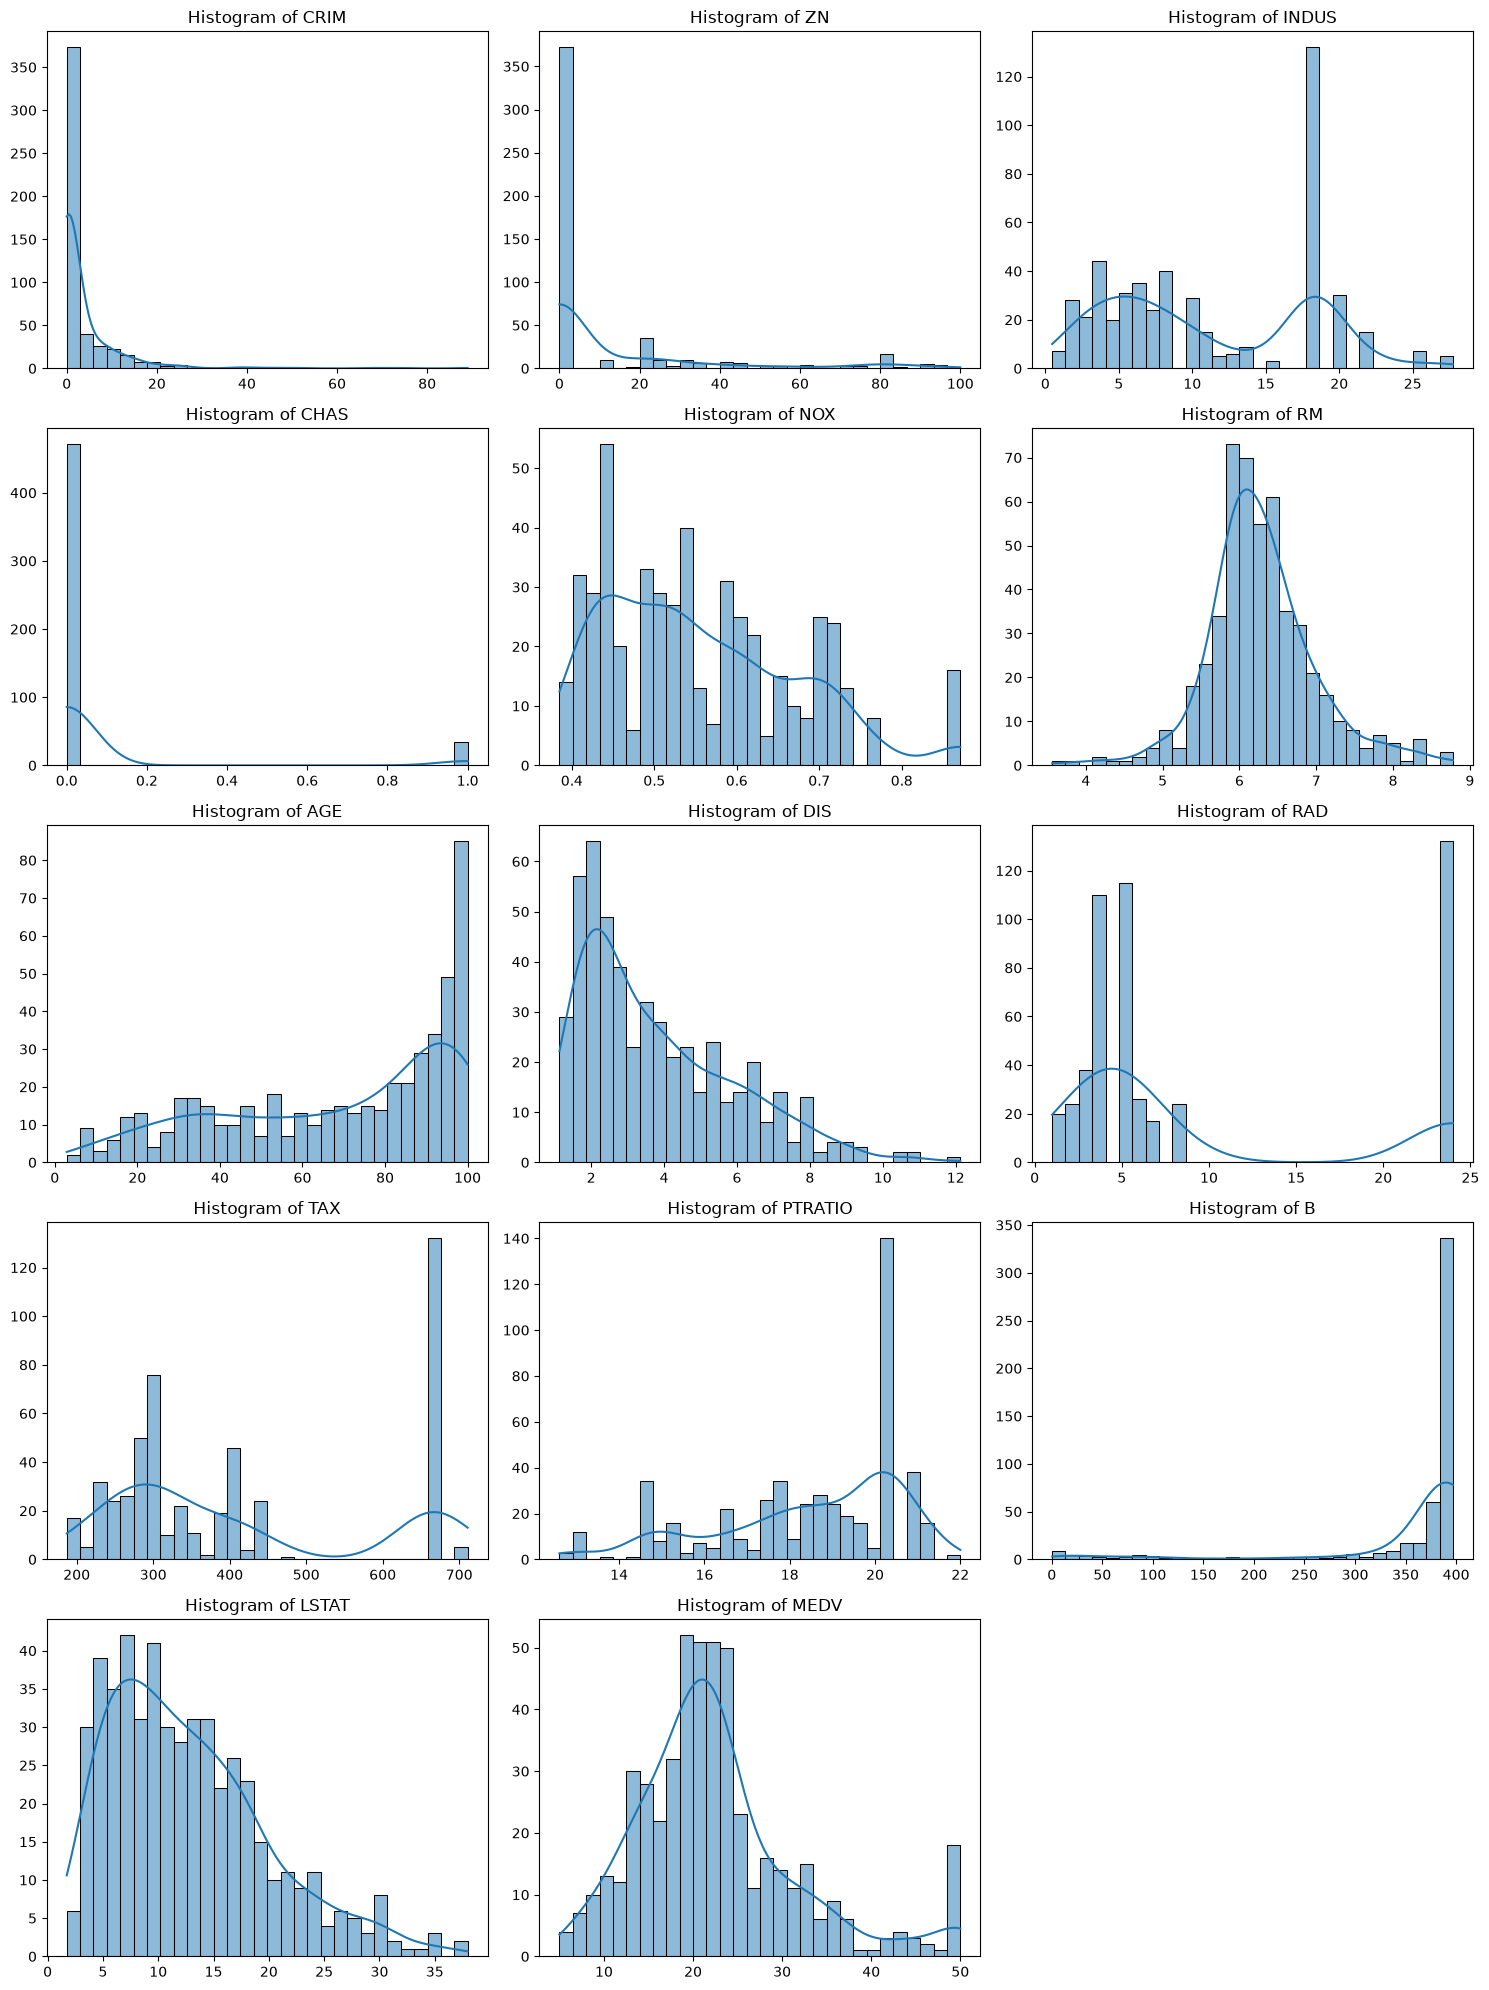

In [7]:
plot_all_histograms(df, title_prefix="Histogram of ")

In [8]:
from scipy.stats import skew

In [9]:
skews = df.apply(skew).sort_values(ascending=False)
print(skews)

CRIM       5.207652
CHAS       3.395799
ZN         2.219063
MEDV       1.104811
DIS        1.008779
RAD        1.001833
LSTAT      0.903771
NOX        0.727144
TAX        0.667968
RM         0.402415
INDUS      0.294146
AGE       -0.597186
PTRATIO   -0.799945
B         -2.881798
dtype: float64


## ✂️ 4. Train/Test Ayrımı / Train/Test Split

**🇹🇷 Türkçe:**
Hedef (`MEDV`) ayrılıp veri %80 eğitim / %20 test olarak bölünüyor.

**🇬🇧 English:**
The target (`MEDV`) is separated and the data split 80% train / 20% test.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer

In [11]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 🔄 5. Yeo-Johnson ile Özellik Dönüşümü / Yeo-Johnson Feature Transform

**🇹🇷 Türkçe:**
`PowerTransformer(method="yeo-johnson")` özelliklere (`X`) uygulanıyor. Box-Cox'un aksine Yeo-Johnson **sıfır ve negatif değerlerle de çalışabiliyor** — burada tam olarak gereken bu, çünkü `CHAS` ikili (0/1) bir kolon ve Box-Cox onu kabul etmezdi. Dönüştürücü sadece `X_train`'e `fit_transform`, `X_test`'e ise `transform` ile uygulanıyor (istatistikler eğitim setinden öğreniliyor). Dönüştürülmüş histogramlar, orijinaline göre gözle görülür biçimde daha simetrik.

**🇬🇧 English:**
`PowerTransformer(method="yeo-johnson")` is applied to the features (`X`). Unlike Box-Cox, Yeo-Johnson **handles zero and negative values** — exactly what's needed here, since `CHAS` is a binary (0/1) column that Box-Cox couldn't accept. The transformer is fit only on `X_train` (`fit_transform`) and just applied (`transform`) to `X_test`, so its statistics come from the training data alone. The transformed histograms are visibly more symmetric than the originals.

In [13]:
pt_X = PowerTransformer(method="yeo-johnson")

X_train_transformed = pt_X.fit_transform(X_train)
X_test_transformed = pt_X.transform(X_test)

In [14]:
column_names_transformed = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

In [15]:
X_train_transformed = pd.DataFrame(X_train_transformed, columns=column_names_transformed)

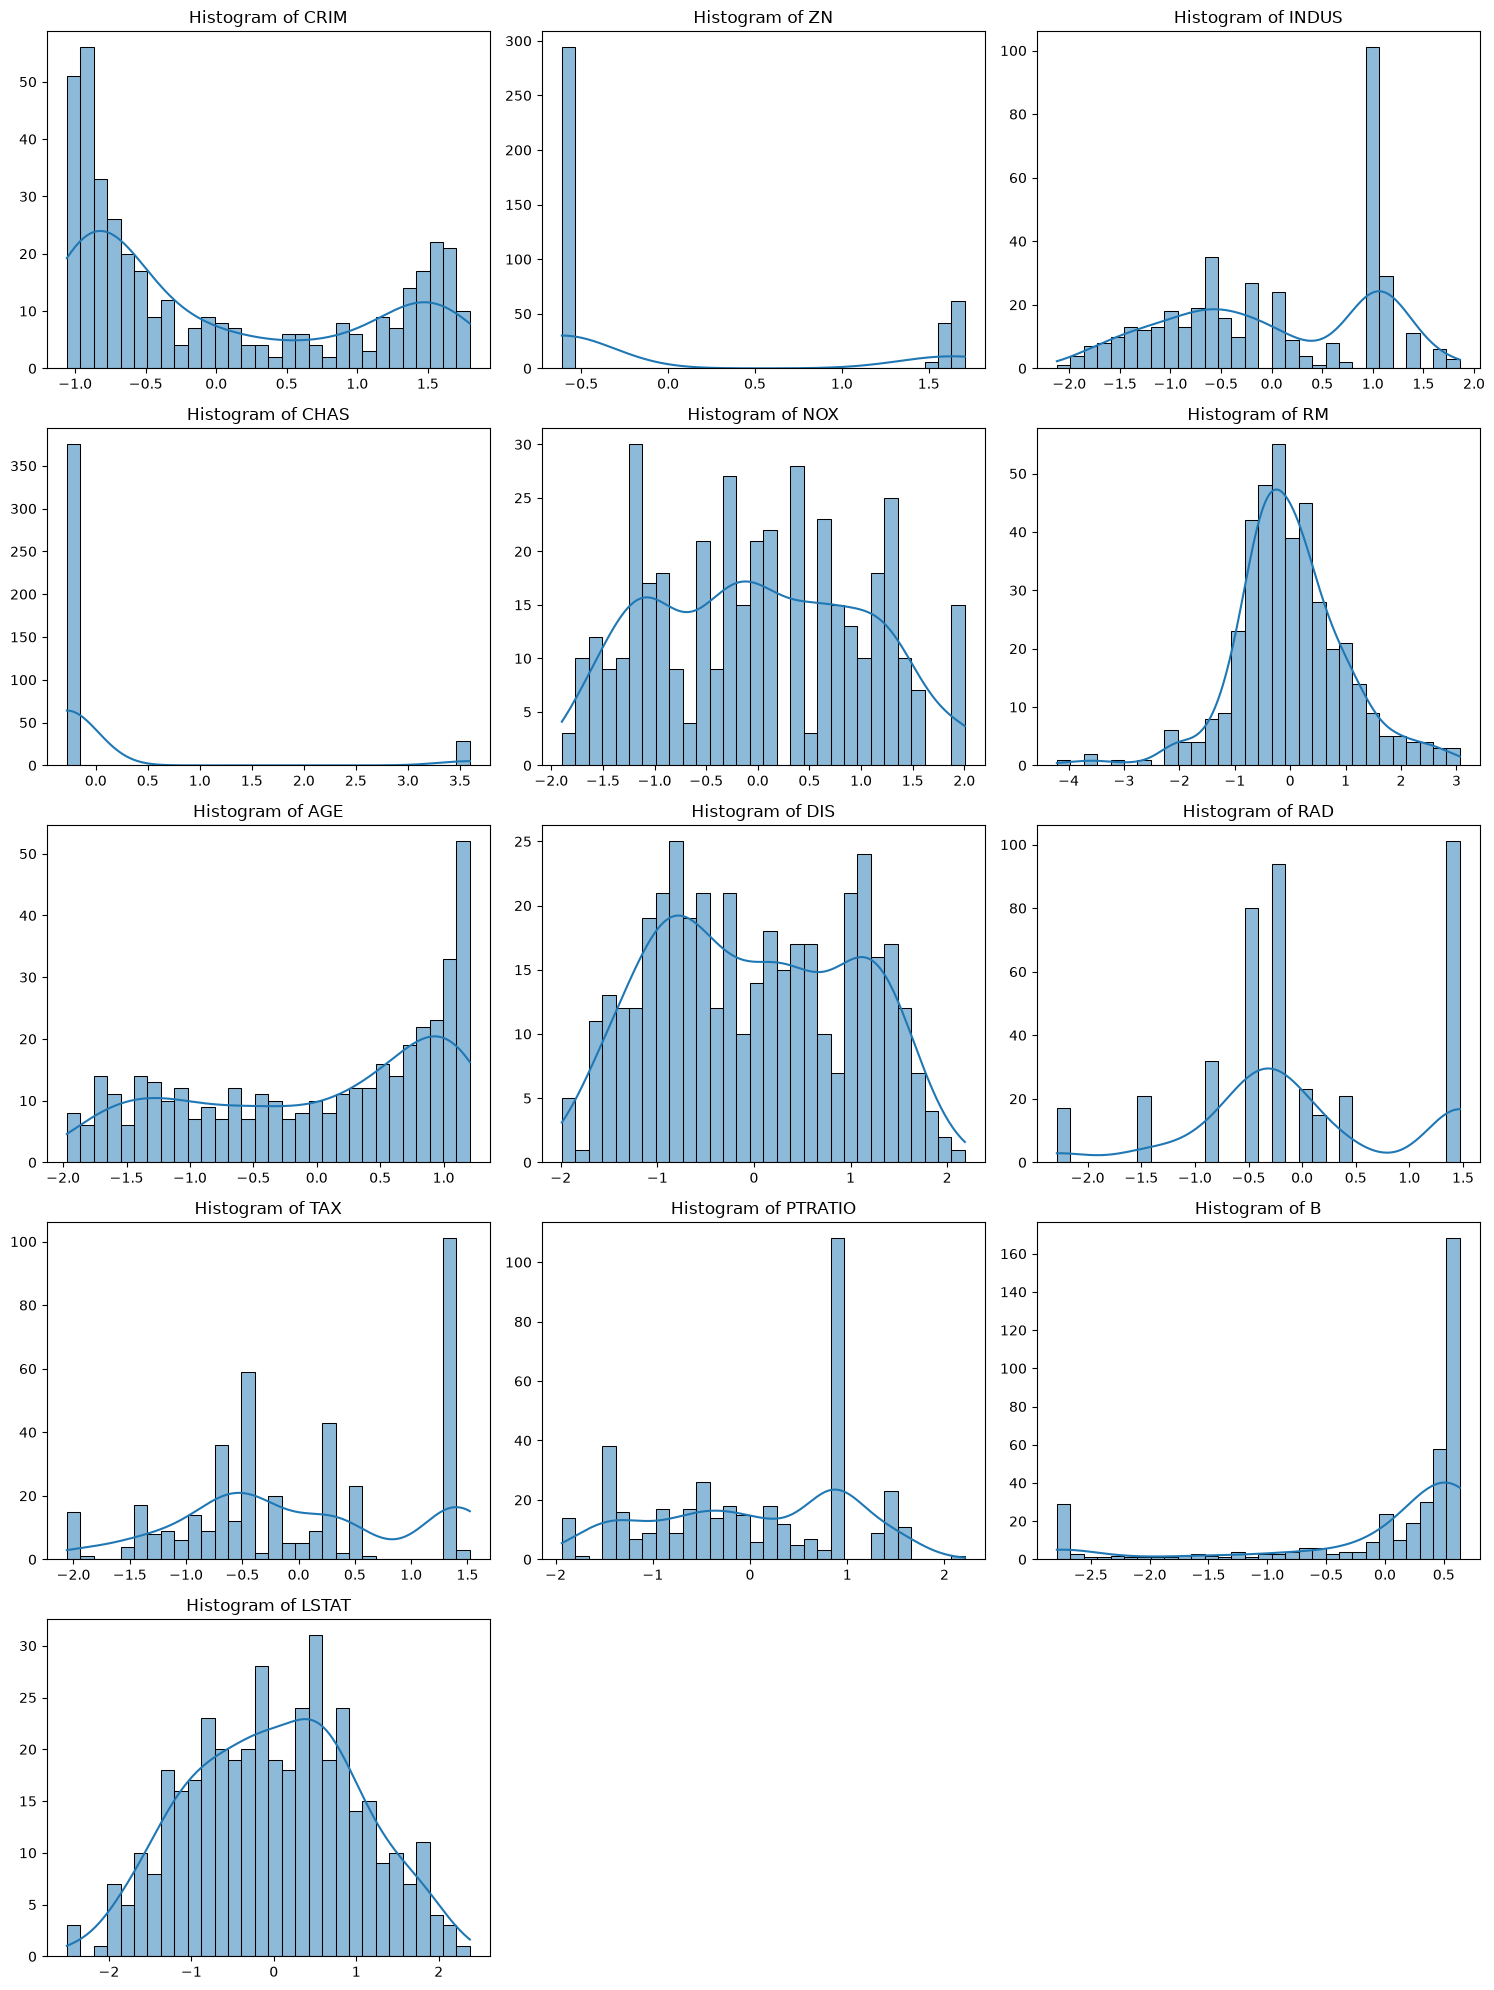

In [16]:
plot_all_histograms(X_train_transformed, title_prefix="Histogram of ")

## 🎯 6. Box-Cox ile Hedef Dönüşümü / Box-Cox Target Transform

**🇹🇷 Türkçe:**
Hedef değişken (`MEDV`, yani `y_train`) `scipy.stats.boxcox` ile dönüştürülüyor. Box-Cox, Yeo-Johnson'ın aksine **kesinlikle pozitif değerler** gerektiriyor — ev fiyatları hiçbir zaman sıfır ya da negatif olamayacağı için bu güvenle sağlanıyor. Fonksiyon, dönüşümü tersine çevirmek için gereken `lambda_y` katsayısını da döndürüyor; bu değer saklanmazsa tahminler orijinal ($) ölçeğe asla geri çevrilemez.

**🇬🇧 English:**
The target (`MEDV`, i.e. `y_train`) is transformed with `scipy.stats.boxcox`. Unlike Yeo-Johnson, Box-Cox requires **strictly positive values** — safely satisfied here since home prices are never zero or negative. The function also returns the `lambda_y` coefficient needed to invert the transform; without saving it, predictions could never be converted back to the original (\$) scale.

In [17]:
from scipy.stats import boxcox

In [18]:
y_train_transformed, lambda_y = boxcox(y_train)

## 🧮 7. Dönüştürülmüş Veriyle Regresyon / Regression on Transformed Data

**🇹🇷 Türkçe:**
`LinearRegression`, Yeo-Johnson ile dönüştürülmüş `X_train` ve Box-Cox ile dönüştürülmüş `y_train_transformed` üzerinde eğitiliyor. Tahminler önce dönüştürülmüş ölçekte üretiliyor, sonra `inverse_boxcox()` ile orijinal dolar ölçeğine geri çevriliyor (`r2_score`/`mean_squared_error` orijinal ölçekte hesaplanmalı, yoksa sonuç yorumlanamaz hale gelir). **Sonuç: R² = 0.7499, RMSE ≈ 4.28** (binlik $).

**🇬🇧 English:**
`LinearRegression` is trained on the Yeo-Johnson-transformed `X_train` and Box-Cox-transformed `y_train_transformed`. Predictions are produced on the transformed scale first, then converted back to the original dollar scale with `inverse_boxcox()` (`r2_score`/`mean_squared_error` must be computed on the original scale, or the result becomes uninterpretable). **Result: R² = 0.7499, RMSE ≈ 4.28** (in \$1,000s).

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
model = LinearRegression()
model.fit(X_train_transformed, y_train_transformed)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.05,-0. ,-0. ,...,-0.13, 0.07,-0.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['CRIM','ZN','INDUS',...,'PTRATIO','B','LSTAT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.354
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [21]:
y_pred_transformed = model.predict(X_test_transformed)

C:\Users\efeka\PycharmProjects\PythonProject1\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

In [23]:
from sklearn.metrics import mean_squared_error, r2_score
print("R2 Score:", r2_score(y_test, y_pred_original))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_original)))

R2 Score: 0.7499247714357344
RMSE: 4.282401497442767


## 📊 8. Karşılaştırma: Ham Veriyle Taban Model / Baseline on Raw Data

**🇹🇷 Türkçe:**
Karşılaştırma için aynı `LinearRegression`, hiçbir dönüşüm uygulanmamış ham `X_train`/`y_train` ile yeniden eğitiliyor. **Sonuç: R² = 0.6688, RMSE ≈ 4.93**.

**🇬🇧 English:**
For comparison, the same `LinearRegression` is retrained on the raw, untransformed `X_train`/`y_train`. **Result: R² = 0.6688, RMSE ≈ 4.93**.

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.11, 0.03, 0.04,...,-0.92, 0.01,-0.51]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['CRIM','ZN','INDUS',...,'PTRATIO','B','LSTAT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30.25
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [25]:
y_pred = model.predict(X_test)

In [26]:
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.6687594935356289
RMSE: 4.928602182665359


## ✅ 9. Sonuçlar ve Notlar / Results and Notes

**🇹🇷 Türkçe:**
| Yaklaşım | R² | RMSE (binlik $) |
|---|---|---|
| Ham veri (dönüşümsüz) | 0.6688 | 4.93 |
| Yeo-Johnson (X) + Box-Cox (y) | **0.7499** | **4.28** |

Güç dönüşümleri, aynı `LinearRegression` modelinde R²'yi **0.6688'den 0.7499'a** çıkarıyor (RMSE'de ≈$0.65 iyileşme) — model değişmedi, sadece verinin ölçeği/dağılımı değişti. Doğrusal regresyon, hataların normal dağıldığı varsayımına dayandığı için, hedefteki ve özelliklerdeki çarpıklığı azaltmak doğrudan performansa yansıyor. Bu, ağaç tabanlı modellerde (LightGBM, XGBoost gibi) genelde gerekmeyen bir adım — onlar dağılımın şekline duyarsız, bölme noktalarını sıraya göre seçiyorlar; ama saf doğrusal modellerde fark yaratıyor.

Küçük bir not: bu notebook'ta `r2_score(y_test, y_pred_original)` çağrıları **doğru sırada** — bir önceki (kronolojik olarak sonraki) `lightgbm_regression.ipynb`'deki `r2_score(y_pred, y_test)` hatası burada yok.

**🇬🇧 English:**
| Approach | R² | RMSE ($1,000s) |
|---|---|---|
| Raw data (no transform) | 0.6688 | 4.93 |
| Yeo-Johnson (X) + Box-Cox (y) | **0.7499** | **4.28** |

Power transforms lift R² from **0.6688 to 0.7499** on the same `LinearRegression` model (≈\$0.65 improvement in RMSE) — the model didn't change, only the scale/shape of the data did. Since linear regression assumes normally distributed errors, reducing skew in the target and features translates directly into performance. This is a step tree-based models (like LightGBM or XGBoost) generally don't need — they're insensitive to distribution shape and choose split points by rank — but it makes a real difference for a plain linear model.

One small note: the `r2_score(y_test, y_pred_original)` calls in this notebook use the **correct argument order** — the `r2_score(y_pred, y_test)` bug found in `lightgbm_regression.ipynb` (built later the same day) doesn't appear here.